# Постановка задачи

Целью данного этапа является построение модели для предсказания значения IC50.

IC50 характеризует эффективность соединения, поэтому задача формулируется как задача регрессии.

Для повышения качества моделей используется логарифмическое преобразование целевой переменной, выявленное на этапе EDA.

# Подготовка данных

In [23]:
import numpy as np
import pandas as pd
import plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, \
    HistGradientBoostingRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:

df = pd.read_excel("../data/compounds.xlsx")

# удаляем мусор
df = df.drop(columns=[col for col in df.columns if "Unnamed" in col], errors="ignore")

target = "IC50, mM"

# лог-таргет
y = np.log1p(df[target])

# признаки
X = df.drop(columns=["IC50, mM", "CC50, mM", "SI"], errors="ignore")

X.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,158,...,0,0,0,0,0,0,0,0,3,0
1,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,162,...,0,0,0,0,0,0,0,0,3,0
2,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,446.458903,186,...,0,0,0,0,0,0,0,0,3,0
3,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,352.311,398.366099,164,...,0,0,0,0,0,0,0,0,4,0
4,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,466.334799,184,...,0,0,0,0,0,0,0,0,0,0


Логарифмическое преобразование применялось только к целевой переменной IC50, так как EDA показал выраженную асимметрию её распределения.

Для признаков будет использоваться масштабирование StandardScaler. Полное логарифмирование всех признаков не будет применяться, поскольку признаки имеют различную природу и распределения, а для моделей на основе деревьев это не является обязательным.

# Train/Test split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
skewness = X.skew()

high_skew = skewness[skewness.abs() > 2].index

print(len(high_skew))

X_log = X.copy()

for col in high_skew:
    if (X_log[col] >= 0).all():
        X_log[col] = np.log1p(X_log[col])

X_train_log, X_test_log, y_train_Log, y_test_log = train_test_split(
    X_log, y, test_size=0.2, random_state=42
)

96


# Baseline

In [5]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

y_pred = dummy.predict(X_test)


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


baseline_metrics = regression_metrics(y_test, y_pred)
baseline_metrics

{'MAE': 1.6329998321330592,
 'RMSE': 3.8923353749969793,
 'R2': -0.011211694356489943}

В качестве baseline используется DummyRegressor, предсказывающий среднее значение.

Это позволяет оценить, насколько модели машинного обучения превосходят простую стратегию.

# Сравнение моделей

Для оценки качества решения были рассмотрены несколько моделей машинного обучения:
- линейные модели
- методы ближайших соседей
- ансамбли деревьев
- бустинговые методы

Сравнение моделей позволит определить, какой тип алгоритмов лучше подходит для задачи предсказания IC50.

In [22]:
models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=10000),
    "KNN": KNeighborsRegressor(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "ExtraTrees": ExtraTreesRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42)
}

In [35]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),  #Удаляем признаки с нулевой дисперсией
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    metrics = regression_metrics(y_test, y_pred)
    metrics["model"] = name

    results.append(metrics)

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

,MAE,RMSE,R2,model
3,1.138920,2.127311,0.447334,RandomForest
6,1.108757,2.141762,0.443580,HistGradientBoosting
5,1.190653,2.241038,0.417788,GradientBoosting
2,1.178834,2.372706,0.383581,KNN
4,1.170817,2.400596,0.376336,ExtraTrees
0,1.301461,2.775919,0.278828,Ridge
1,1.633000,3.892335,-0.011212,Lasso


In [34]:
results_log = []

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train_log, y_train_Log)
    y_pred = pipe.predict(X_test_log)

    metrics_log = regression_metrics(y_test_log, y_pred)
    metrics_log["model"] = name
    results_log.append(metrics_log)

results_df_log = pd.DataFrame(results_log).sort_values("RMSE")
results_df_log

,MAE,RMSE,R2,model
3,1.140471,2.135452,0.445219,RandomForest
6,1.108757,2.141762,0.443580,HistGradientBoosting
5,1.193346,2.249182,0.415672,GradientBoosting
4,1.159609,2.355062,0.388165,ExtraTrees
2,1.204313,2.399776,0.376549,KNN
0,1.331964,2.860435,0.256872,Ridge
1,1.633000,3.892335,-0.011212,Lasso


По результатам сравнения видно, что наилучшее качество показывают ансамблевые методы, особенно RandomForest и HistGradientBoosting.

Линейные модели работают заметно хуже, что подтверждает выводы EDA об отсутствии выраженной линейной зависимости в данных.

Логарифмирование признаков не дало заметного улучшения качества моделей.
Лучший результат по-прежнему показывает RandomForest, а метрики почти не изменились.

Это говорит о том, что для данной задачи достаточно:
- логарифмировать целевую переменную IC50
- заполнять пропуски медианой
- удалять признаки с нулевой дисперсией
- масштабировать признаки для моделей, чувствительных к масштабу

Дополнительное логарифмирование признаков не используется как основной вариант подготовки данных.

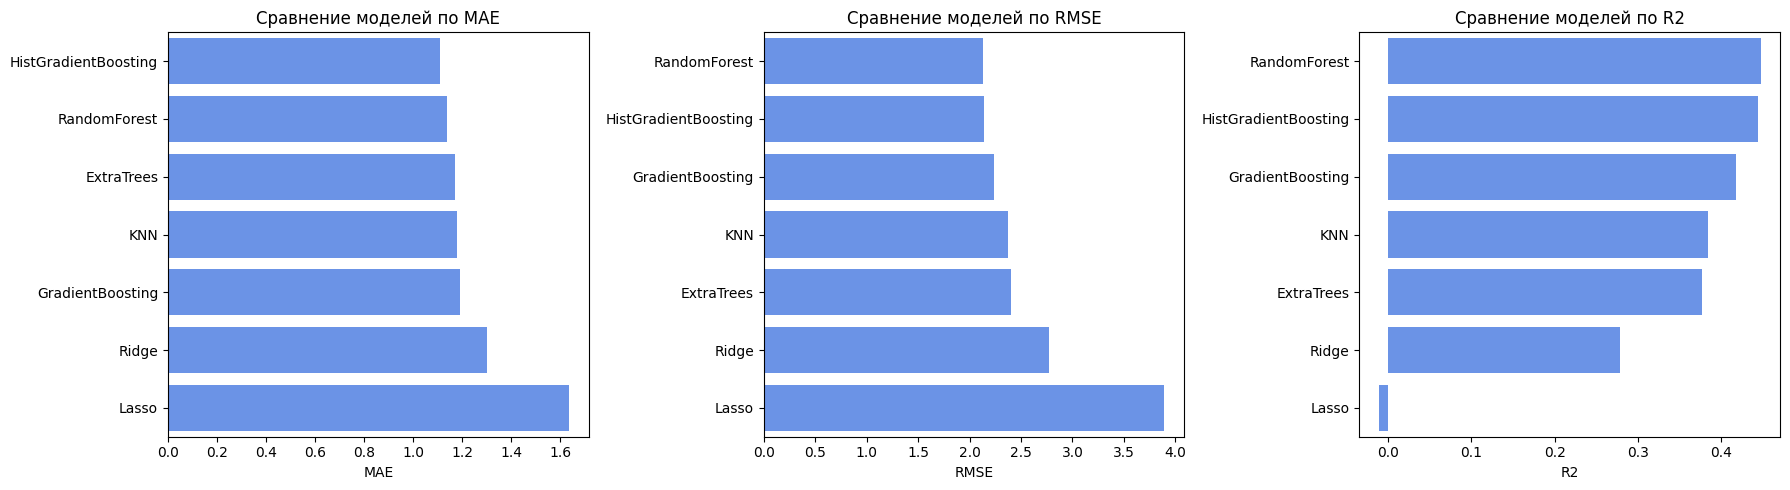

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ["MAE", "RMSE", "R2"]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=results_df.sort_values(metric, ascending=(metric != "R2")),
        x=metric,
        y="model",
        ax=axes[i]
    )
    axes[i].set_title(f"Сравнение моделей по {metric}")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

Несмотря на наличие коррелирующих признаков, для моделей на основе деревьев это не является критичной проблемой, поэтому признаки не удалялись.

# Подбор гиперпараметров

После первичного сравнения моделей выполняется подбор гиперпараметров для наиболее перспективной модели.

По 2м показателям RMSE и R2 RandomForestRegressor показывает лучший результат, поэтому для неё выполняется подбор гиперпараметров.
Это позволяет дополнительно повысить качество предсказания и подобрать более оптимальную конфигурацию модели.

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance", VarianceThreshold(threshold=0.0)),  #Удаляем признаки с нулевой дисперсией
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42))
])

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="neg_root_mean_squared_error")
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(best_model)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('variance', VarianceThreshold()), ('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(max_depth=10, min_samples_split=10,
                                       n_estimators=300, random_state=42))])


Подбор гиперпараметров позволил улучшить качество модели за счёт более удачного выбора глубины деревьев и количества оценщиков.

# Визуализация

Для более детального анализа качества модели рассмотрим визуализации предсказаний и ошибок модели.

Это позволит понять:
- насколько хорошо модель предсказывает реальные значения
- есть ли систематические ошибки
- на каких объектах модель работает хуже

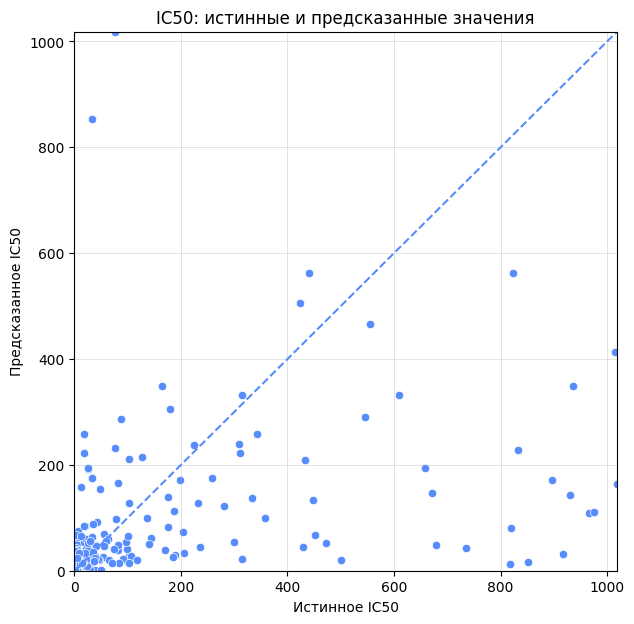

In [39]:
y_pred_log = best_model.predict(X_test)

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)
limit = np.percentile(
    np.concatenate([y_test_real, y_pred_real]),
    95
)

plt.figure(figsize=(7, 7))

sns.scatterplot(
    x=y_test_real,
    y=y_pred_real
)

plt.plot([0, limit], [0, limit], linestyle="--")

plt.xlim(0, limit)
plt.ylim(0, limit)

plt.xlabel("Истинное IC50")
plt.ylabel("Предсказанное IC50")
plt.title("IC50: истинные и предсказанные значения")

plt.grid()
plt.show()

График показывает, что модель улавливает общую зависимость между истинными и предсказанными значениями IC50: при увеличении реального значения предсказание также в среднем увеличивается.

При этом наблюдается заметный разброс точек относительно диагонали, что говорит о наличии ошибок предсказания и сложности задачи.

Наибольшие ошибки возникают для больших значений IC50. Это может быть связано с тем, что экстремальные значения встречаются значительно реже, и модель имеет меньше примеров для их обучения.

Для основной массы объектов с относительно небольшими значениями IC50 качество предсказаний заметно выше.

# Распределение ошибок

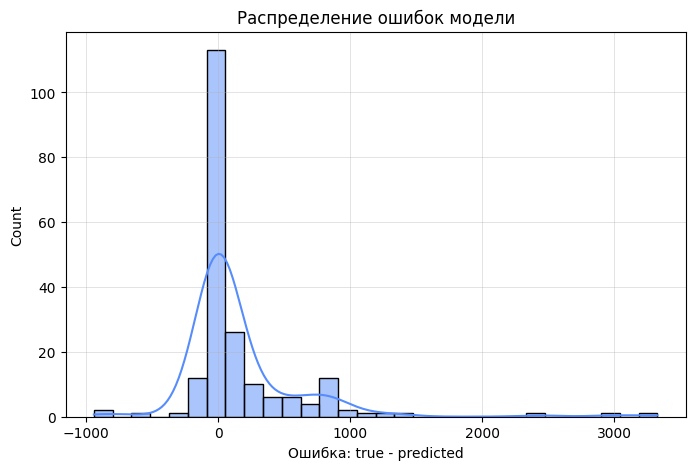

In [17]:
residuals = y_test_real - y_pred_real

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Ошибка: true - predicted")
plt.title("Распределение ошибок модели")
plt.grid()
plt.show()

Распределение ошибок показывает, что большинство предсказаний модели имеют относительно небольшую ошибку и сосредоточены около нуля.

Это говорит о том, что модель в среднем не имеет сильного систематического смещения и предсказывает IC50 достаточно стабильно для основной массы объектов.

При этом наблюдается выраженный правый хвост распределения ошибок. Это означает, что на части объектов модель существенно занижает большие значения IC50.

Подобное поведение связано с наличием редких экстремальных значений в данных, количество которых значительно меньше по сравнению с основной массой наблюдений.

# Ошибка относительно истинного значения

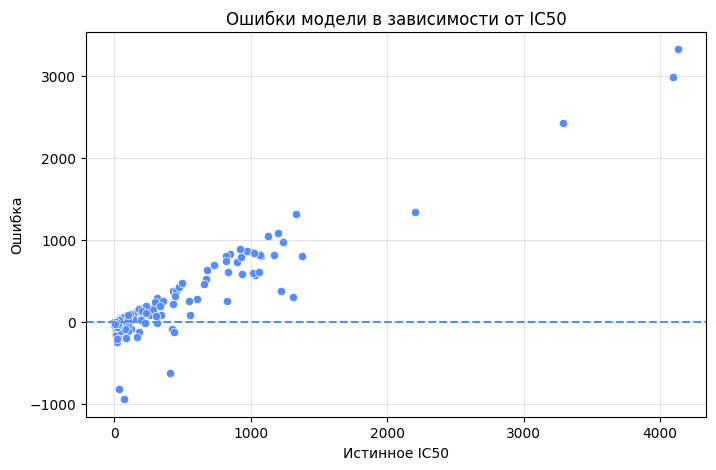

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test_real, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Истинное IC50")
plt.ylabel("Ошибка")
plt.title("Ошибки модели в зависимости от IC50")
plt.grid()
plt.show()

График показывает, что для большинства объектов с небольшими значениями IC50 ошибки модели остаются относительно малыми.

Однако при увеличении IC50 ошибка начинает возрастать, причём модель в большинстве случаев занижает большие значения IC50.

Это говорит о том, что модель лучше работает на основной массе данных и хуже справляется с редкими экстремальными значениями, которые представлены в выборке значительно реже.

# Feature importance для лучшей модели

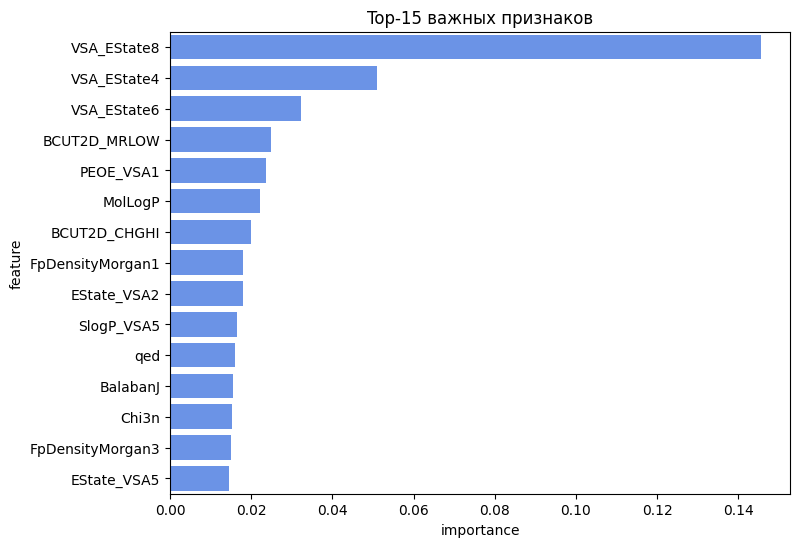

In [19]:
model = best_model.named_steps["model"]

if hasattr(model, "feature_importances_"):
    feature_names = X.columns

    # если был VarianceThreshold
    if "variance" in best_model.named_steps:
        mask = best_model.named_steps["variance"].get_support()
        feature_names = feature_names[mask]

    importances = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=importances, x="importance", y="feature")
    plt.title("Top-15 важных признаков")
    plt.show()

График важности признаков показывает, что модель использует сразу несколько характеристик соединений для предсказания IC50.

Наиболее значимым признаком оказался VSA_EState8, однако заметный вклад вносят и другие признаки, что говорит о сложной структуре данных.

Отсутствие одного доминирующего признака подтверждает, что задача не сводится к простой зависимости и требует использования моделей, способных учитывать комбинации признаков и нелинейные связи.

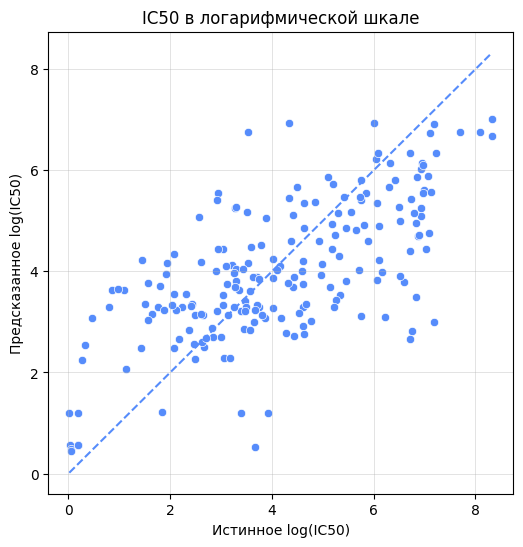

In [20]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_log)

min_val = min(y_test.min(), y_pred_log.min())
max_val = max(y_test.max(), y_pred_log.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Истинное log(IC50)")
plt.ylabel("Предсказанное log(IC50)")
plt.title("IC50 в логарифмической шкале")
plt.grid()
plt.show()

В логарифмической шкале зависимость между истинными и предсказанными значениями становится значительно более выраженной.

Точки располагаются ближе к диагонали, что говорит о том, что модель хорошо улавливает общую структуру данных после логарифмического преобразования целевой переменной.

При этом для части объектов, особенно с большими значениями IC50, сохраняется заметный разброс предсказаний, что указывает на сложность задачи и наличие редких экстремальных значений.

# Выводы

В рамках задачи была построена и исследована модель для предсказания значения IC50.

Перед обучением моделей была выполнена подготовка данных:
- пропущенные значения заменялись медианой
- удалялись признаки с нулевой дисперсией
- использовалось масштабирование признаков
- для целевой переменной применялось логарифмическое преобразование

Сравнение моделей показало, что линейные методы (Ridge, Lasso) демонстрируют более низкое качество, что подтверждает выводы EDA об отсутствии выраженной линейной зависимости в данных.

Наилучшие результаты показали ансамблевые методы, особенно RandomForest и HistGradientBoosting. Это связано с их способностью учитывать сложные нелинейные зависимости и устойчивостью к выбросам.

Дополнительный эксперимент с логарифмированием признаков не привёл к заметному улучшению качества моделей. В связи с этим в качестве основного варианта подготовки данных было решено использовать только логарифмирование целевой переменной IC50.

Анализ визуализаций показал, что:
- модель хорошо улавливает общую зависимость между признаками и IC50
- качество предсказаний для основной массы объектов является удовлетворительным
- наибольшие ошибки возникают для редких экстремальных значений IC50

В логарифмической шкале структура данных и качество предсказаний становятся значительно более выраженными, что дополнительно подтверждает корректность применения логарифмического преобразования.

Анализ важности признаков показал, что модель использует сразу несколько характеристик соединений, а не опирается только на один признак. Это говорит о сложной природе зависимости IC50 от химических характеристик соединений.

Таким образом, для задачи предсказания IC50 наиболее эффективными оказались ансамблевые методы, способные работать с нелинейными зависимостями и сложной структурой данных.